In [1]:
#03_business_value.ipynb
#
#by Joe Hahn
#jmh.datasciences@gmail.com
#6 August 2026
#
#goal: use the model to choose WHO to contact in the client's next marketing campaign, ie
#to make it TARGETED, and put a dollar value on that versus working the list at random.
#this model's job is to make sure those contacted are customers most likely to buy

In [2]:
#start time
import time as tm
clock_start = tm.time()

In [3]:
#import python libraries
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)
import warnings
warnings.filterwarnings('ignore')

In [4]:
#import plotting libraries
#use following line when in Jupyter
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')

In [5]:
#input parameters. the client is assumed to be an enterprise tax-software vendor, so the following
#ML-powered campaign is presumed to span across millions of customers 
test_file = 'test.parquet'
model_file = 'models.joblib'
y_col = 'target'
campaign_size = 2000000     #2M customers in one annual campaign
contact_cost = 3            #$3 per touch, blended digital and outbound
margin_per_sale = 80        #gross margin on one licence
campaign_budget = 1200000   #$1.2M the client has for this campaign
good_market = 2.0           #interest rate below this counts as a good selling market
print('campaign_size     = ', format(campaign_size, ','), ' customers')
print('contact_cost      = $', contact_cost, ' per touch')
print('margin_per_sale   = $', margin_per_sale)
contact_budget = campaign_budget/(contact_cost*campaign_size)   #so this share of the list
print('campaign_budget   = $', format(campaign_budget, ','), ' = ',
      format(int(campaign_budget/contact_cost), ','), ' contacts = ',
      round(100*contact_budget), '% of the list')

campaign_size     =  2,000,000  customers
contact_cost      = $ 3  per touch
margin_per_sale   = $ 80
campaign_budget   = $ 1,200,000  =  400,000  contacts =  20 % of the list


In [6]:
#score every customer in the test sample using the gradient boosting ML model
import joblib
test = pd.read_parquet(test_file)
model = joblib.load(model_file)['gradient boosting']
x_cols = [c for c in test.columns if c != y_col]
scored = test.copy()
scored['p_buy'] = model.predict_proba(test[x_cols])[:, 1]
print('scored ', format(len(scored), ','), ' customers')
scored[['age', 'employment', 'prior_campaign_outcome*', 'euribor_3m*', y_col, 'p_buy']].sample(
    5, random_state=14).round(3)

scored  10,297  customers


,age,employment,prior_campaign_outcome*,euribor_3m*,target,p_buy
30939,29,student,-1,1.406,0,0.265
24470,45,management,-1,4.856,0,0.038
33100,33,assistant,-1,0.659,0,0.485
40088,36,laborer,-1,1.281,0,0.106
38050,50,assistant,yes,0.714,0,0.601


## 1. what the model buys you in easy market having euribor_3m < 2%

In [7]:
#select records obtained when market was 'easy', euribor_3m < 2%, and sales were more probable,
#then rank by p_buy to build a call list. later we'll review outcomes in a 'hard' market
df = scored[scored['euribor_3m*'] < good_market].sort_values('p_buy', ascending=False)
N_customers = len(df)
N_buyers = int(df[y_col].sum())
print('customers on the list = ', format(N_customers, ','))
print('buyers among them     = ', format(N_buyers, ','), ' (', round(100.0*N_buyers/N_customers, 1), '%)')

customers on the list =  3,408
buyers among them     =  824  ( 24.2 %)


In [8]:
#rank the list by p_buy, then work our way down it: if we call only the top X%, how many of the
#buyers do we reach, and what share of those contacts actually convert?
df['calls'] = np.arange(1, N_customers + 1)
df['sales'] = df[y_col].cumsum()
gains = []
for frac in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.75, 1.00]:
    k = int(N_customers*frac)
    row = df.iloc[k - 1]
    gains.append({'call_top': str(int(100*frac)) + '%', 'calls': k, 'sales': int(row.sales),
                  'share_of_buyers': row.sales/N_buyers, 'conversion_rate': row.sales/k,
                  'lift_vs_random': (row.sales/k)/(N_buyers*1.0/N_customers)})
gains = pd.DataFrame(gains)
print('calling everyone closes ', round(100.0*N_buyers/N_customers, 1), '% of the time,')
print('so any conversion_rate above that is what the model is adding')
gains.round(3)

calling everyone closes  24.2 % of the time,
so any conversion_rate above that is what the model is adding


,call_top,calls,sales,share_of_buyers,conversion_rate,lift_vs_random
0,5%,170,134,0.163,0.788,3.260
1,10%,340,236,0.286,0.694,2.871
2,20%,681,399,0.484,0.586,2.423
3,30%,1022,524,0.636,0.513,2.121
4,40%,1363,622,0.755,0.456,1.887
5,50%,1704,703,0.853,0.413,1.706
6,75%,2556,781,0.948,0.306,1.264
7,100%,3408,824,1.000,0.242,1.000


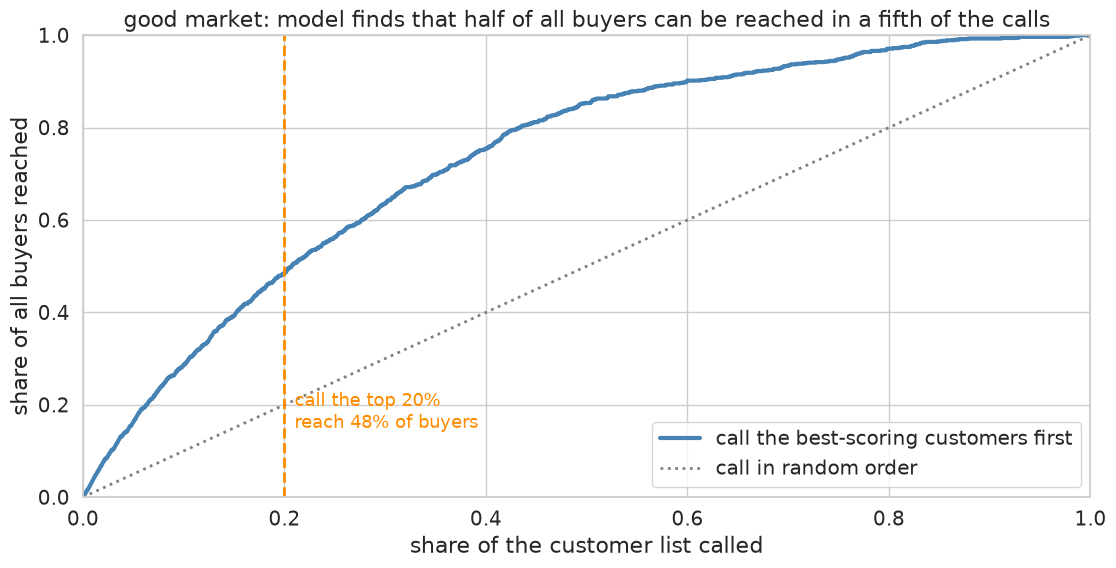

In [9]:
#plot the share of all buyers we reach against the share of the list we contact.
#the diagonal is what working the list in random order gets you
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 6))
xp = df.calls/N_customers
yp = df.sales/N_buyers
p = ax.plot(xp, yp, linewidth=3, color='steelblue', label='call the best-scoring customers first')
p = ax.plot([0, 1], [0, 1], linestyle=':', linewidth=2, color='grey', label='call in random order')
p = ax.axvline(0.20, color='darkorange', linestyle='--', linewidth=2)
p = ax.text(0.21, 0.15, 'call the top 20%\nreach ' + str(round(100*gains.share_of_buyers[2])) 
            + '% of buyers', fontsize=13, color='darkorange')
p = ax.set_xlim(0, 1)
p = ax.set_ylim(0, 1)
p = ax.set_title('good market: model finds that half of all buyers can be reached in a fifth of the calls')
p = ax.set_xlabel('share of the customer list called')
p = ax.set_ylabel('share of all buyers reached')
p = ax.legend(loc='lower right')

## 2. what a fixed campaign budget buys

In [10]:
#in good market conditions a 2M customer list holds about 0.5M buyers. but the budget only
#covers a fraction of that list, so use the model to reach out to most rewarding customers
total_buyers = campaign_size*N_buyers/N_customers
print('sell rate in the good market  = ', round(100.0*N_buyers/N_customers, 1), '%')
print('scaled to ', format(campaign_size, ','), ' customers = ',
      format(int(total_buyers), ','), ' buyers to find')

sell rate in the good market  =  24.2 %
scaled to  2,000,000  customers =  483,568  buyers to find


In [11]:
#what each budget level is worth, model versus picking the same number of customers at random
value = []
for frac in [0.05, 0.10, 0.20, 0.30, 0.50]:
    k = int(N_customers*frac)
    reach = df[y_col].iloc[:k].sum()/N_buyers        #share of buyers the model reaches
    contacts = int(campaign_size*frac)
    sales_model = total_buyers*reach
    sales_random = total_buyers*frac
    value.append({'contact_top': str(int(100*frac)) + '%', 'contacts': format(contacts, ','),
                  'spend': '$' + str(round(contacts*contact_cost/1e6, 1)) + 'M',
                  'revenue_no_model': '$' + str(round(sales_random*margin_per_sale/1e6, 1)) + 'M',
                  'revenue_w_model': '$' + str(round(sales_model*margin_per_sale/1e6, 1)) + 'M',
                  'extra_sales': format(int(sales_model - sales_random), ','),
                  'extra_revenue': '$' + str(round((sales_model - sales_random)*margin_per_sale/1e6, 1)) + 'M'})
pd.DataFrame(value)

,contact_top,contacts,spend,revenue_no_model,revenue_w_model,extra_sales,extra_revenue
0,5%,"100,000",$0.3M,$1.9M,$6.3M,"54,460",$4.4M
1,10%,"200,000",$0.6M,$3.9M,$11.1M,"90,140",$7.2M
2,20%,"400,000",$1.2M,$7.7M,$18.7M,"137,441",$11.0M
3,30%,"600,000",$1.8M,$11.6M,$24.6M,"162,441",$13.0M
4,50%,"1,000,000",$3.0M,$19.3M,$33.0M,"170,774",$13.7M


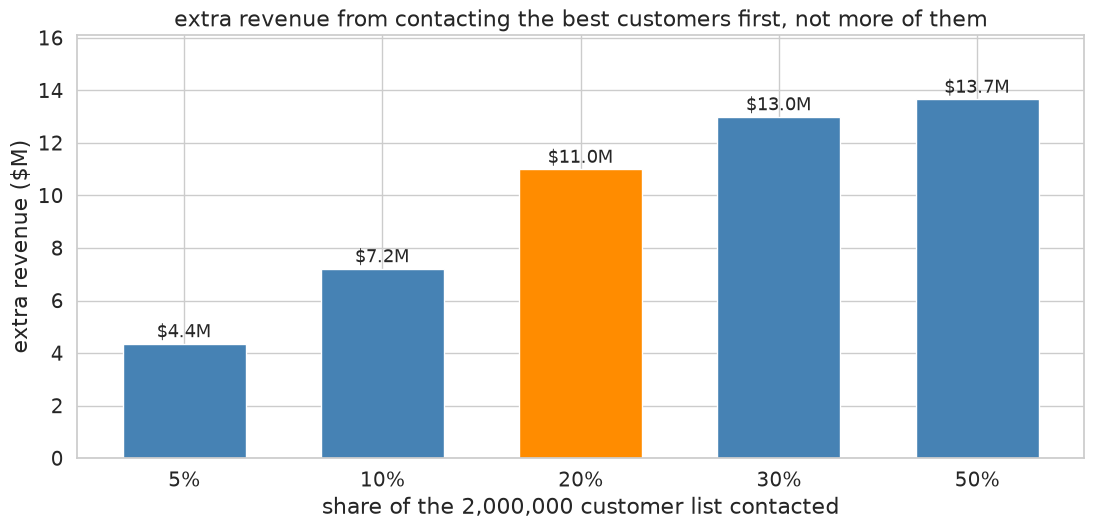

contacting the best  20 % of  2,000,000  customers:
   reaches       48.4 % of all buyers, against  20 % picking at random
   extra sales   137,441
   extra revenue $ 11.0 M
   per contact  $ 27.49   <- each call is worth this much more because the model picked who to make it to

that is the size of the prize. what it takes to capture it in production...the
scoring pipeline, the CRM integration and the retraining loop...is the next
conversation, once we have agreed an architecture


In [12]:
#plot it...the money chart. same spend either way, so the whole bar is incremental,
#then state the headline for the budget the client has actually set
k = int(N_customers*contact_budget)
reach = df[y_col].iloc[:k].sum()/N_buyers
extra_sales = total_buyers*(reach - contact_budget)
extra_revenue = extra_sales*margin_per_sale

sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5.5))
fracs = [0.05, 0.10, 0.20, 0.30, 0.50]
xp = np.arange(len(fracs))
yp = [total_buyers*(df[y_col].iloc[:int(N_customers*f)].sum()/N_buyers - f)*margin_per_sale/1e6
      for f in fracs]
colors = ['darkorange' if abs(f - contact_budget) < 0.001 else 'steelblue' for f in fracs]
p = ax.bar(xp, yp, color=colors, width=0.62)
for jdx in range(len(fracs)):
    p = ax.text(jdx, yp[jdx] + 0.25, '$' + str(round(yp[jdx], 1)) + 'M', ha='center', fontsize=13)
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(int(100*f)) + '%' for f in fracs])
p = ax.set_ylim(0, max(yp)*1.18)
p = ax.set_title('extra revenue from contacting the best customers first, not more of them')
p = ax.set_xlabel('share of the ' + format(campaign_size, ',') + ' customer list contacted')
p = ax.set_ylabel('extra revenue ($M)')
plt.show()

print('contacting the best ', round(100*contact_budget), '% of ', format(campaign_size, ','),
      ' customers:')
print('   reaches      ', round(100*reach, 1), '% of all buyers, against ',
      round(100*contact_budget), '% picking at random')
print('   extra sales  ', format(int(extra_sales), ','))
print('   extra revenue $', round(extra_revenue/1e6, 1), 'M')
print('   per contact  $', round(extra_revenue/(campaign_size*contact_budget), 2),
      '  <- each call is worth this much more because the model picked who to make it to')
print()
print('that is the size of the prize. what it takes to capture it in production...the')
print('scoring pipeline, the CRM integration and the retraining loop...is the next')
print('conversation, once we have agreed an architecture')

## 3. what happens in a hard market?

In [13]:
#the good market above is the friendly case. run the same arithmetic on the hard market,
#where rates were high and almost nobody bought
hard = scored[scored['euribor_3m*'] >= 4].sort_values('p_buy', ascending=False)
hard_base = hard[y_col].mean()
k = int(len(hard)*contact_budget)
hard_reach = hard[y_col].iloc[:k].sum()/hard[y_col].sum()
hard_buyers = campaign_size*hard_base
hard_extra = hard_buyers*(hard_reach - contact_budget)*margin_per_sale
print('hard market sell rate = ', round(100*hard_base, 1), '% against ',
      round(100.0*N_buyers/N_customers, 1), '% in a good one')
print('contacting the best ', round(100*contact_budget), '% reaches ',
      round(100*hard_reach, 1), '% of buyers, against ', round(100*contact_budget), '% at random')
print('extra revenue = $', round(hard_extra/1e6, 1), 'M, against $',
      round(extra_revenue/1e6, 1), 'M in a good market')
print()
print('so the same model earns about ', round(extra_revenue/hard_extra, 0),
      'x less when the market turns. still worth running, but the business')
print('case has to be rechecked when conditions move rather than assumed')

hard market sell rate =  4.9 % against  24.2 % in a good one
contacting the best  20 % reaches  32.8 % of buyers, against  20 % at random
extra revenue = $ 1.0 M, against $ 11.0 M in a good market

so the same model earns about  11.0 x less when the market turns. still worth running, but the business
case has to be rechecked when conditions move rather than assumed


## what we found

| finding | what it means for the business |
|---|---|
| in a good market the best 20% of the list holds 48% of the buyers | same contact spend, roughly 2.4x the sales |
| targeting that 20% adds +137,000 sales, about `$11M`, on a 2M customer campaign | `$27` more per call: `$47` revenue per call w/model vs `$19` without |
| a hard market cuts that gain from `$11M` to about `$1M` | we do not know which market today is, so build now and be ready to harvest the full reward when it turns easy |

### what we would do next

- **agree a production architecture and cost it.** this pilot shows the prize is real;
  the next step is how the scoring pipeline, CRM integration and retraining loop bolt
  onto the existing platform, and what that takes to build and run.
- **timestamp the records.** the calendar was lost before we saw the data, so we cannot
  separate real seasonality from the economy, and we cannot validate the model the way it
  will actually be used, on tomorrow's customers rather than a random sample.
- **record which rep made which call**, and the outcome of each attempt. the score also
  sorts the list by how hard the sale is, so with rep-level data we could test whether
  routing easy wins to new reps and the uncertain middle to seasoned ones actually pays.
- **capture the actual revenue per sale.** we used a placeholder; real figures would
  sharpen the stopping point.
- **record why the no's said no.** objection reasons are the most likely source of a
  genuinely better model, more so than more customers of the kind we already have.
- **fix two data problems at source:** the 990 customers missing both loan fields, and
  the `c10` column that duplicated the answer.

In [14]:
#done
print('execution time (min) = ', round((tm.time() - clock_start)/60.0, 2))

execution time (min) =  0.02
